In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [8]:
!mv "archive (1).zip" dataset.zip
!unzip dataset.zip -d dataset

Archive:  dataset.zip
  inflating: dataset/test_zip/test/apple_77.jpg  
  inflating: dataset/test_zip/test/apple_77.xml  
  inflating: dataset/test_zip/test/apple_78.jpg  
  inflating: dataset/test_zip/test/apple_78.xml  
  inflating: dataset/test_zip/test/apple_79.jpg  
  inflating: dataset/test_zip/test/apple_79.xml  
  inflating: dataset/test_zip/test/apple_80.jpg  
  inflating: dataset/test_zip/test/apple_80.xml  
  inflating: dataset/test_zip/test/apple_81.jpg  
  inflating: dataset/test_zip/test/apple_81.xml  
  inflating: dataset/test_zip/test/apple_82.jpg  
  inflating: dataset/test_zip/test/apple_82.xml  
  inflating: dataset/test_zip/test/apple_83.jpg  
  inflating: dataset/test_zip/test/apple_83.xml  
  inflating: dataset/test_zip/test/apple_84.jpg  
  inflating: dataset/test_zip/test/apple_84.xml  
  inflating: dataset/test_zip/test/apple_85.jpg  
  inflating: dataset/test_zip/test/apple_85.xml  
  inflating: dataset/test_zip/test/apple_86.jpg  
  inflating: dataset/test_zi

In [12]:
!mv dataset/train_zip/train dataset/
!mv dataset/test_zip/test dataset/

In [13]:
import os
print(os.listdir("dataset"))

['train_zip', 'train', 'test', 'test_zip']


In [14]:
print(os.listdir("dataset/train"))

['banana_28.jpg', 'banana_49.jpg', 'apple_72.xml', 'apple_14.jpg', 'orange_16.xml', 'mixed_12.jpg', 'banana_62.xml', 'orange_70.xml', 'apple_2.xml', 'banana_16.jpg', 'orange_22.jpg', 'orange_15.xml', 'banana_32.jpg', 'apple_22.jpg', 'banana_43.jpg', 'mixed_11.xml', 'orange_67.jpg', 'apple_27.jpg', 'banana_10.xml', 'apple_67.jpg', 'orange_52.xml', 'banana_44.xml', 'apple_37.xml', 'banana_20.jpg', 'banana_27.xml', 'banana_35.jpg', 'orange_27.xml', 'orange_12.xml', 'orange_37.jpg', 'banana_37.jpg', 'mixed_5.jpg', 'banana_36.jpg', 'apple_44.jpg', 'banana_34.jpg', 'apple_27.xml', 'orange_46.jpg', 'mixed_13.xml', 'orange_43.jpg', 'orange_50.jpg', 'banana_33.jpg', 'banana_66.xml', 'banana_10.jpg', 'apple_36.jpg', 'banana_53.xml', 'banana_65.xml', 'banana_61.xml', 'apple_69.xml', 'banana_5.xml', 'banana_14.xml', 'apple_49.xml', 'banana_72.xml', 'banana_28.xml', 'orange_35.jpg', 'orange_46.xml', 'orange_21.xml', 'mixed_14.xml', 'banana_67.jpg', 'orange_21.jpg', 'orange_73.xml', 'apple_52.jpg', 

In [17]:
import os
import xml.etree.ElementTree as ET

data_path = "dataset/train"
yolo_labels_path = "dataset/train/labels"

os.makedirs(yolo_labels_path, exist_ok=True)

classes = ["apple", "banana", "orange"]

def convert_xml_to_yolo(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    img_w = int(root.find("size/width").text)
    img_h = int(root.find("size/height").text)

    if img_w == 0 or img_h == 0:
        return []

    yolo_data = []

    for obj in root.findall("object"):
        cls = obj.find("name").text
        if cls not in classes:
            continue

        cls_id = classes.index(cls)

        xml_box = obj.find("bndbox")
        xmin = int(xml_box.find("xmin").text)
        ymin = int(xml_box.find("ymin").text)
        xmax = int(xml_box.find("xmax").text)
        ymax = int(xml_box.find("ymax").text)

        # Convert
        x_center = (xmin + xmax) / 2 / img_w
        y_center = (ymin + ymax) / 2 / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        yolo_data.append(f"{cls_id} {x_center} {y_center} {width} {height}")

    return yolo_data


# Convert all XML files
for file in os.listdir(data_path):
    if file.endswith(".xml"):
        xml_path = os.path.join(data_path, file)
        yolo_labels = convert_xml_to_yolo(xml_path)

        if not yolo_labels:
            continue

        txt_file = file.replace(".xml", ".txt")
        txt_path = os.path.join(yolo_labels_path, txt_file)

        with open(txt_path, "w") as f:
            f.write("\n".join(yolo_labels))

print("Conversion Completed")

Conversion Completed


In [20]:
#Move images into images/ folder
import os
import shutil
img_folder = "dataset/train/images"
os.makedirs(img_folder, exist_ok=True)
for file in os.listdir("dataset/train"):
    if file.endswith(".jpg"):
        shutil.move(os.path.join("dataset/train", file),
                    os.path.join(img_folder, file))

print("Images moved ")

Images moved 


In [21]:
print(os.listdir("dataset/train"))
print(os.listdir("dataset/train/images")[:5])
print(os.listdir("dataset/train/labels")[:5])

['apple_72.xml', 'orange_16.xml', 'banana_62.xml', 'orange_70.xml', 'apple_2.xml', 'orange_15.xml', 'mixed_11.xml', 'banana_10.xml', 'orange_52.xml', 'banana_44.xml', 'apple_37.xml', 'banana_27.xml', 'orange_27.xml', 'orange_12.xml', 'apple_27.xml', 'mixed_13.xml', 'banana_66.xml', 'banana_53.xml', 'banana_65.xml', 'banana_61.xml', 'apple_69.xml', 'banana_5.xml', 'banana_14.xml', 'apple_49.xml', 'banana_72.xml', 'banana_28.xml', 'orange_46.xml', 'orange_21.xml', 'mixed_14.xml', 'orange_73.xml', 'apple_42.xml', 'orange_74.xml', 'orange_35.xml', 'banana_41.xml', 'apple_19.xml', 'orange_50.xml', 'apple_29.xml', 'banana_74.xml', 'orange_8.xml', 'images', 'apple_40.xml', 'orange_29.xml', 'apple_74.xml', 'orange_63.xml', 'apple_28.xml', 'banana_7.xml', 'banana_30.xml', 'mixed_18.xml', 'mixed_4.xml', 'banana_70.xml', 'apple_48.xml', 'apple_76.xml', 'banana_26.xml', 'orange_64.xml', 'orange_28.xml', 'banana_40.xml', 'banana_37.xml', 'orange_57.xml', 'banana_42.xml', 'orange_56.xml', 'apple_46.

In [22]:
#Create data.yaml
data_yaml = """
path: dataset
train: train/images
val: train/images

names:
  0: apple
  1: banana
  2: orange
"""

with open("dataset/data.yaml", "w") as f:
    f.write(data_yaml)
print("data.yaml created")

data.yaml created


In [23]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.train(
    data="dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e550aa06e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

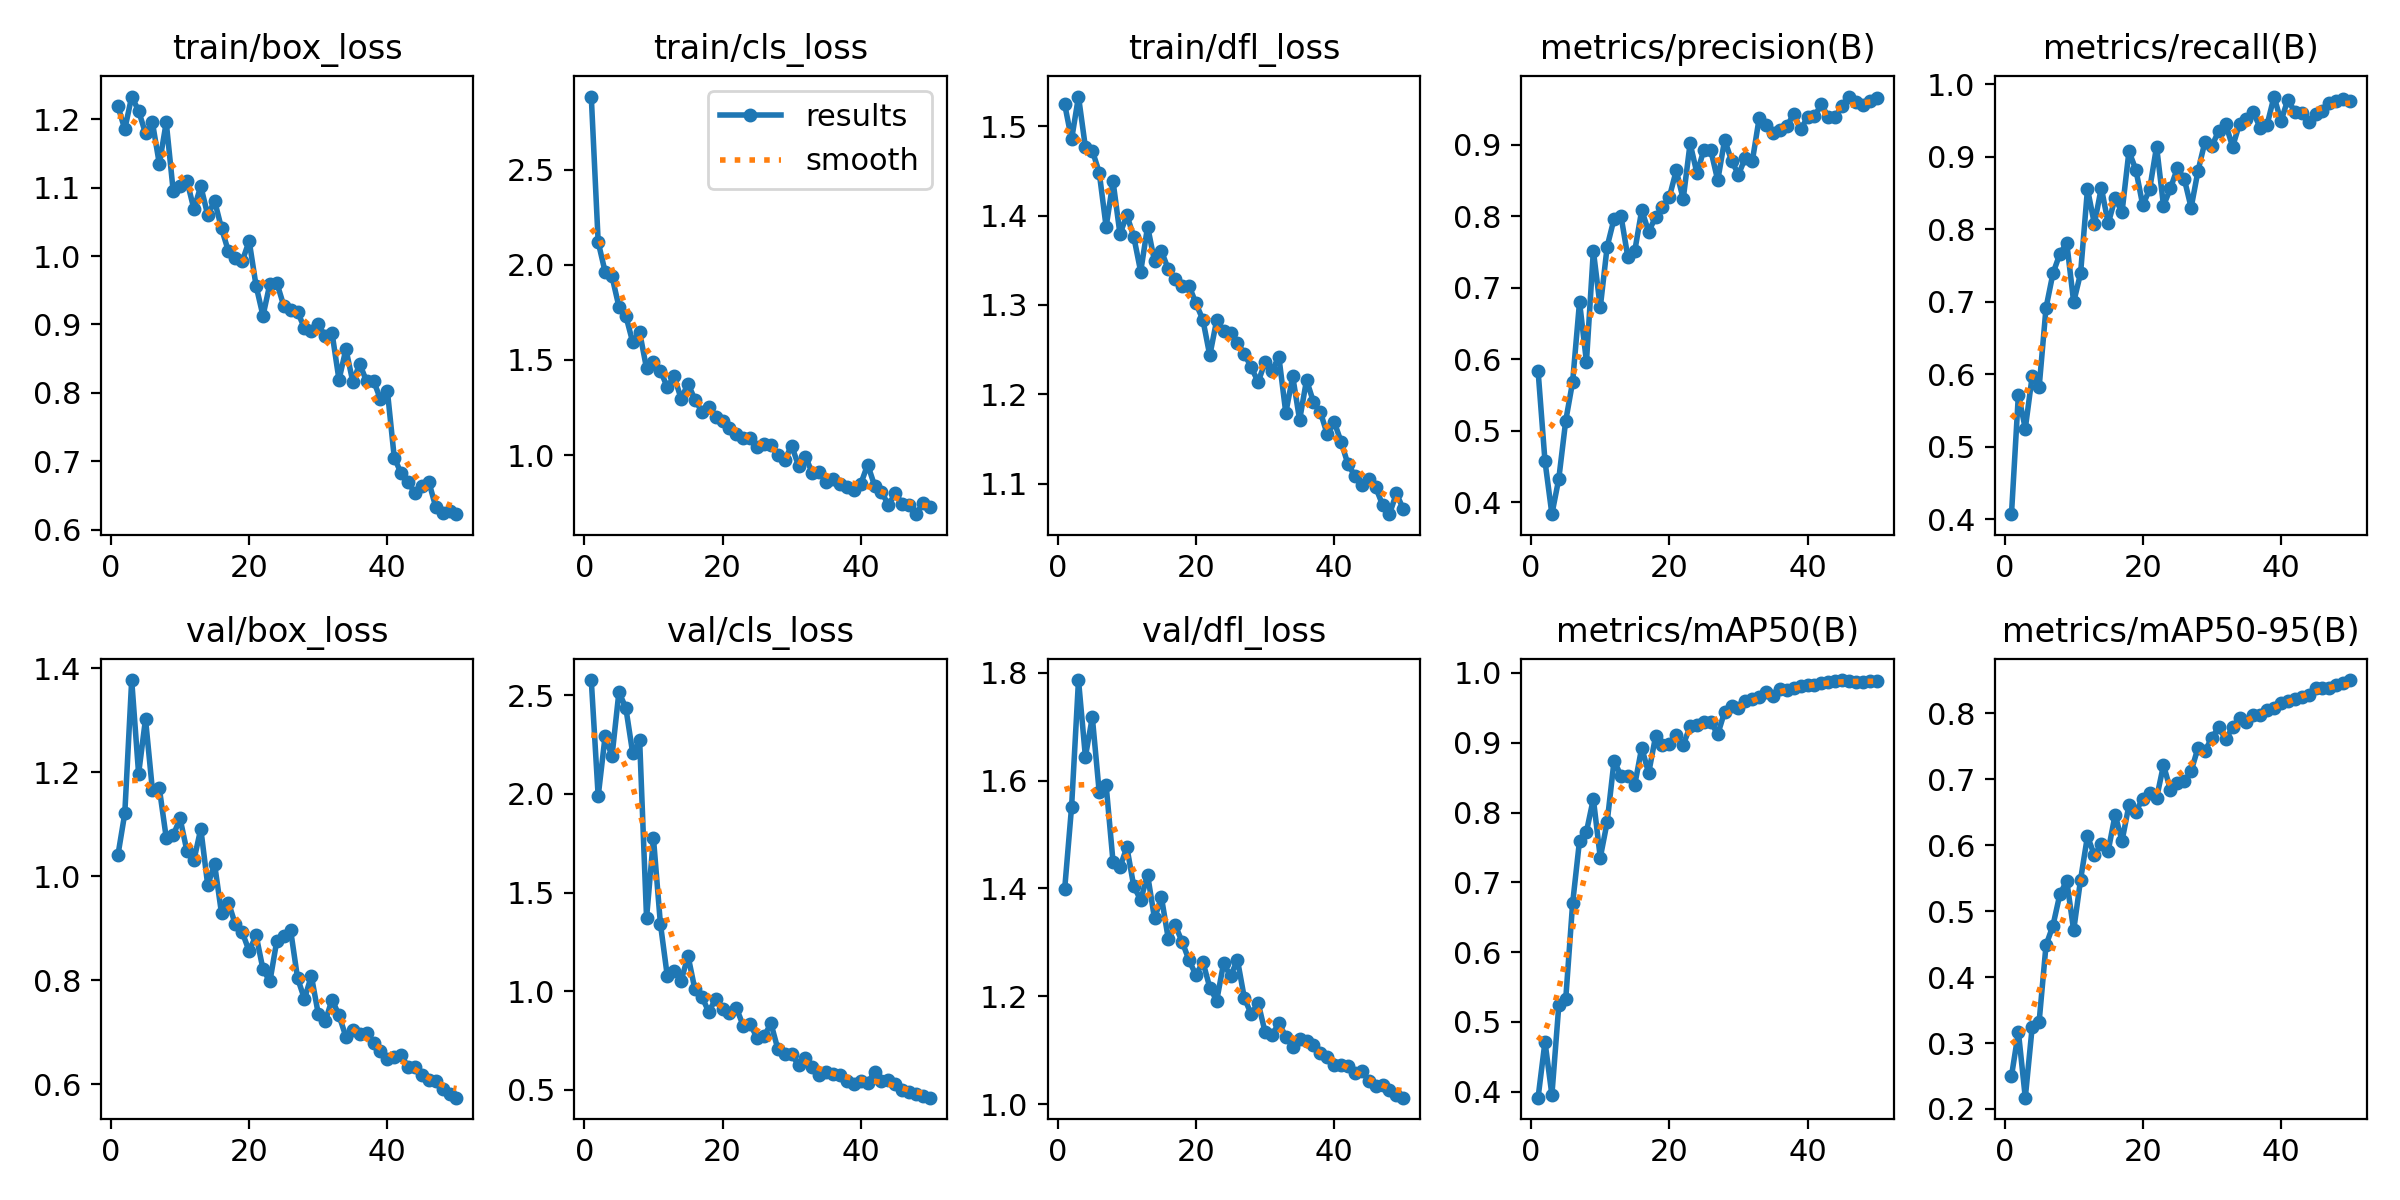

In [24]:
from IPython.display import Image
Image("runs/detect/train/results.png")


Processing: banana_28.jpg

image 1/1 /content/dataset/train/images/banana_28.jpg: 640x640 1 banana, 9.7ms
Speed: 4.2ms preprocess, 9.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


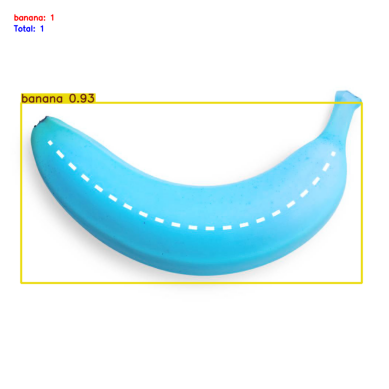


Processing: banana_49.jpg

image 1/1 /content/dataset/train/images/banana_49.jpg: 320x640 1 banana, 11.7ms
Speed: 3.1ms preprocess, 11.7ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 640)


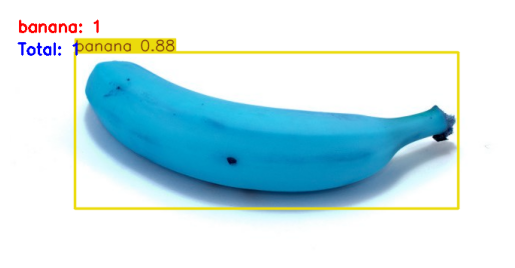


Processing: apple_14.jpg

image 1/1 /content/dataset/train/images/apple_14.jpg: 448x640 1 apple, 20.1ms
Speed: 5.4ms preprocess, 20.1ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)


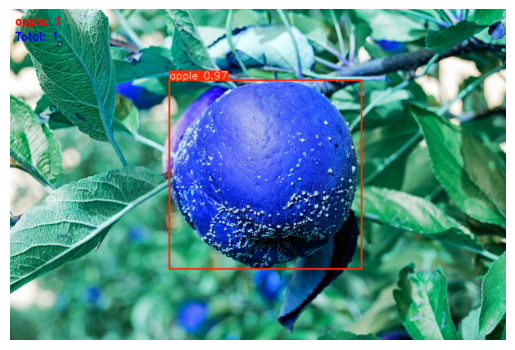


Processing: mixed_12.jpg

image 1/1 /content/dataset/train/images/mixed_12.jpg: 416x640 1 apple, 1 banana, 1 orange, 9.8ms
Speed: 3.5ms preprocess, 9.8ms inference, 1.9ms postprocess per image at shape (1, 3, 416, 640)


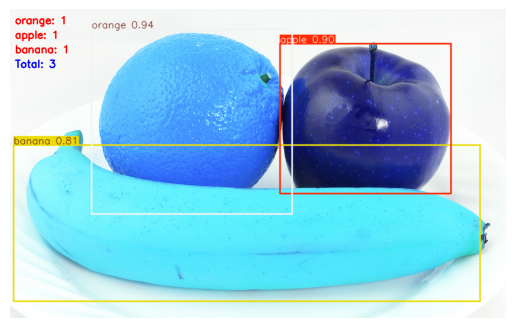


Processing: banana_16.jpg

image 1/1 /content/dataset/train/images/banana_16.jpg: 384x640 1 banana, 11.7ms
Speed: 3.3ms preprocess, 11.7ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


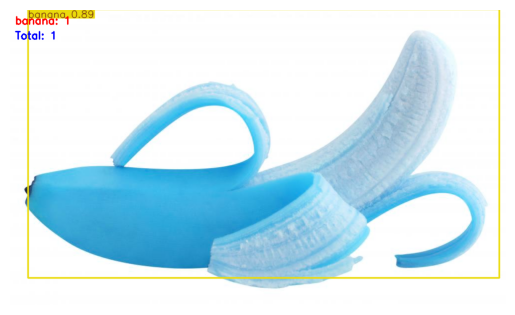

In [34]:
import os
import cv2
import matplotlib.pyplot as plt

img_folder = "dataset/train/images"
images = os.listdir(img_folder)[:5]

for img_name in images:
    print("\nProcessing:", img_name)

    results = model(os.path.join(img_folder, img_name))

    for r in results:
        img = r.plot()

        boxes = r.boxes
        class_ids = boxes.cls.tolist()
        names = model.names

        counts = {}

        for cls_id in class_ids:
            cls_name = names[int(cls_id)]
            counts[cls_name] = counts.get(cls_name, 0) + 1

        y_offset = 30
        for k, v in counts.items():
            cv2.putText(img, f"{k}: {v}", (10, y_offset),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                        (255, 0, 0), 2)
            y_offset += 30

        cv2.putText(img, f"Total: {len(class_ids)}",
                    (10, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (0, 0, 255), 2)

        plt.imshow(img)
        plt.axis("off")
        plt.show()